# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [2]:
df_prep = pd.read_csv('../data/checker_submits.csv')

df_prep['timestamp'] = pd.to_datetime(df_prep['timestamp'])
df_prep['hour'] = df_prep['timestamp'].dt.hour
df_prep['dayofweek'] = df_prep['timestamp'].dt.dayofweek

df_prep.head(20)

,uid,labname,numTrials,timestamp,hour,dayofweek
0,user_4,project1,1,2020-04-17 05:19:02.744528,5,4
1,user_4,project1,2,2020-04-17 05:22:45.549397,5,4
2,user_4,project1,3,2020-04-17 05:34:24.422370,5,4
3,user_4,project1,4,2020-04-17 05:43:27.773992,5,4
4,user_4,project1,5,2020-04-17 05:46:32.275104,5,4
5,user_4,project1,6,2020-04-17 05:50:27.860908,5,4
6,user_4,project1,7,2020-04-17 05:52:56.335091,5,4
7,user_4,laba04,1,2020-04-17 11:33:17.366400,11,4
8,user_4,laba04,2,2020-04-17 11:40:05.237273,11,4
9,user_4,laba04,3,2020-04-17 11:44:20.707058,11,4


In [3]:
enc = OneHotEncoder(handle_unknown='ignore', sparse=False)
onehot_columns = enc.fit_transform(df_prep[['uid','labname']])

feature_names = []
for i, feature in enumerate(['uid', 'labname']):
    for j, category in enumerate(enc.categories_[i]):
        feature_names.append(f"{feature}_{category}")

df_enc = pd.DataFrame(onehot_columns, columns=feature_names)
df_prep = pd.concat([df_prep, df_enc], axis=1, join='outer')
df_prep = df_prep.drop(['uid', 'labname', 'timestamp'], axis=1)

df_prep.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [4]:
scaler = StandardScaler()

df_scaler = scaler.fit_transform(df_prep[['numTrials', 'hour']])

df_prep[['numTrials', 'hour']] = df_scaler

df_prep.to_csv('../data/dayofweek.csv', index=False)

df_prep.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
most_popular_day = df_prep['dayofweek'].mode()[0]

accuracy_naive = accuracy_score(df_prep['dayofweek'], [most_popular_day] * len(df_prep))
print(f"Точность наивного алгоритма: {accuracy_naive}")

Точность наивного алгоритма: 0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [6]:
X = df_prep.drop(columns='dayofweek')
y = df_prep['dayofweek']

In [7]:
model = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')

model = model.fit(X, y)

print(f'Точность модели логистической регрессии:{model.score(X, y)}')

Точность модели логистической регрессии:0.6215895610913404


In [8]:
logreg_coefs = pd.DataFrame(model.coef_)

In [9]:
def plot_barh(coef, features, top_n = 10):
    if coef.ndim == 1:
        importance = np.abs(coef)
    else:
        importance = np.sum(np.abs(coef), axis=0)
    
    sorted_indices = np.argsort(importance)[-top_n:]
    sorted_importance = importance[sorted_indices]
    sorted_features = features[sorted_indices]
    
    plt.barh(sorted_features, sorted_importance)

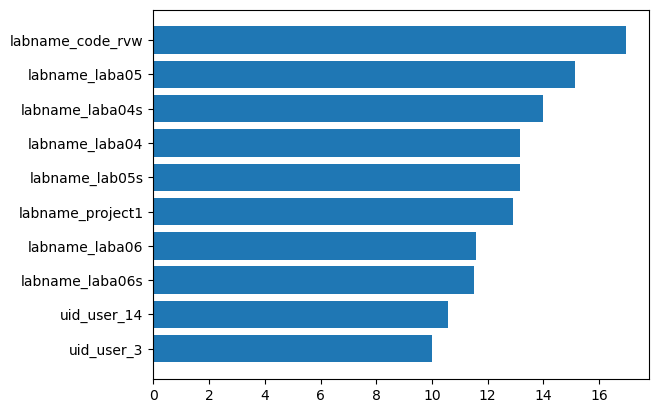

In [10]:
plot_barh(logreg_coefs, X.columns)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [11]:
model_linear = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))

model_linear = model_linear.fit(X, y)
y_pred = model_linear.predict(X)

accuracy = accuracy_score(y, y_pred)

print(f'Точность ядра "linear" составляет: {accuracy}')

Точность ядра "linear" составляет: 0.6120996441281139


In [12]:
pipeline = Pipeline([('svc', SVC())])

param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid']
    }

grid_search = GridSearchCV(pipeline, param_grid, scoring='accuracy')

grid_search = grid_search.fit(X, y)
y_pred = grid_search.predict(X)

best_kernel = grid_search.best_params_['svc__kernel']
accuracy = accuracy_score(y, y_pred)

print(f'Лучшим ядром является: "{best_kernel}", его точность составляет {accuracy}')

Лучшим ядром является: "poly", его точность составляет 0.8594306049822064


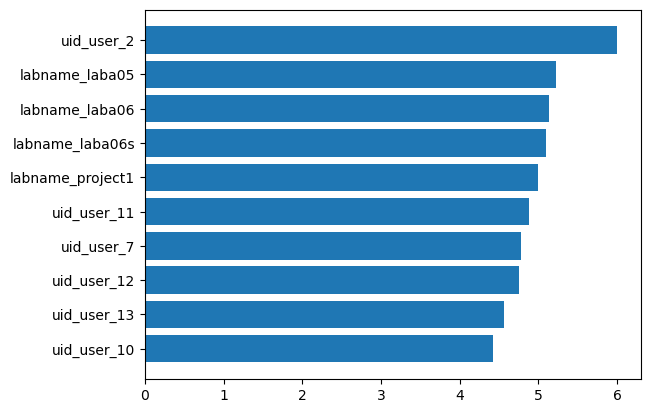

In [13]:
coef_matrix = np.array([estimator.coef_[0] for estimator in model_linear.estimators_])

plot_barh(coef_matrix, X.columns)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [14]:
model = DecisionTreeClassifier(max_depth=4, random_state=21)

model = model.fit(X, y)

model.score(X, y)

0.5516014234875445

In [15]:
for i in range(1, 28, 2):
    model = DecisionTreeClassifier(max_depth=i, random_state=21)
    model = model.fit(X, y)
    accuracy = model.score(X, y)
    print(f'При max_depth = {i}, accuracy = {accuracy}')

При max_depth = 1, accuracy = 0.35765124555160144
При max_depth = 3, accuracy = 0.48991696322657174
При max_depth = 5, accuracy = 0.6109134045077106
При max_depth = 7, accuracy = 0.7064056939501779
При max_depth = 9, accuracy = 0.7846975088967971
При max_depth = 11, accuracy = 0.8499406880189798
При max_depth = 13, accuracy = 0.9104389086595492
При max_depth = 15, accuracy = 0.9460260972716489
При max_depth = 17, accuracy = 0.9709371293001187
При max_depth = 19, accuracy = 0.9839857651245552
При max_depth = 21, accuracy = 0.9905100830367735
При max_depth = 23, accuracy = 0.9934756820877817
При max_depth = 25, accuracy = 0.99644128113879
При max_depth = 27, accuracy = 0.998220640569395


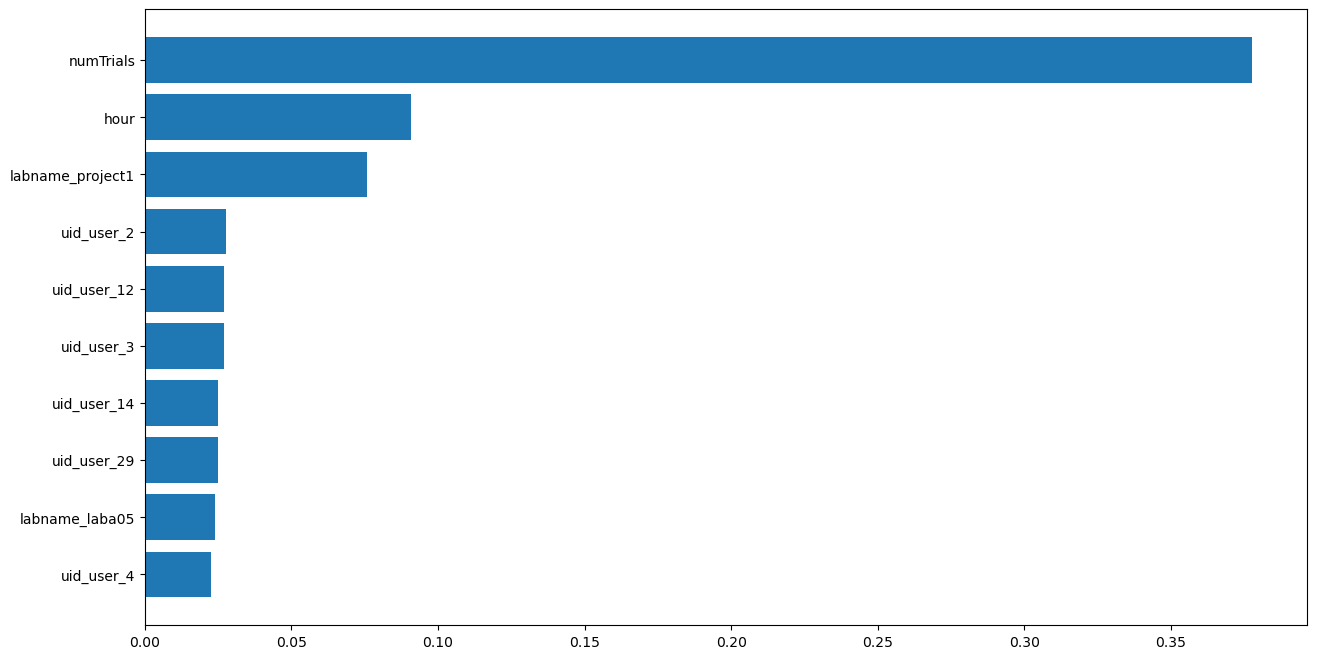

In [16]:
plt.figure(figsize=(15, 8))
plot_barh(model.feature_importances_, X.columns)
plt.show()

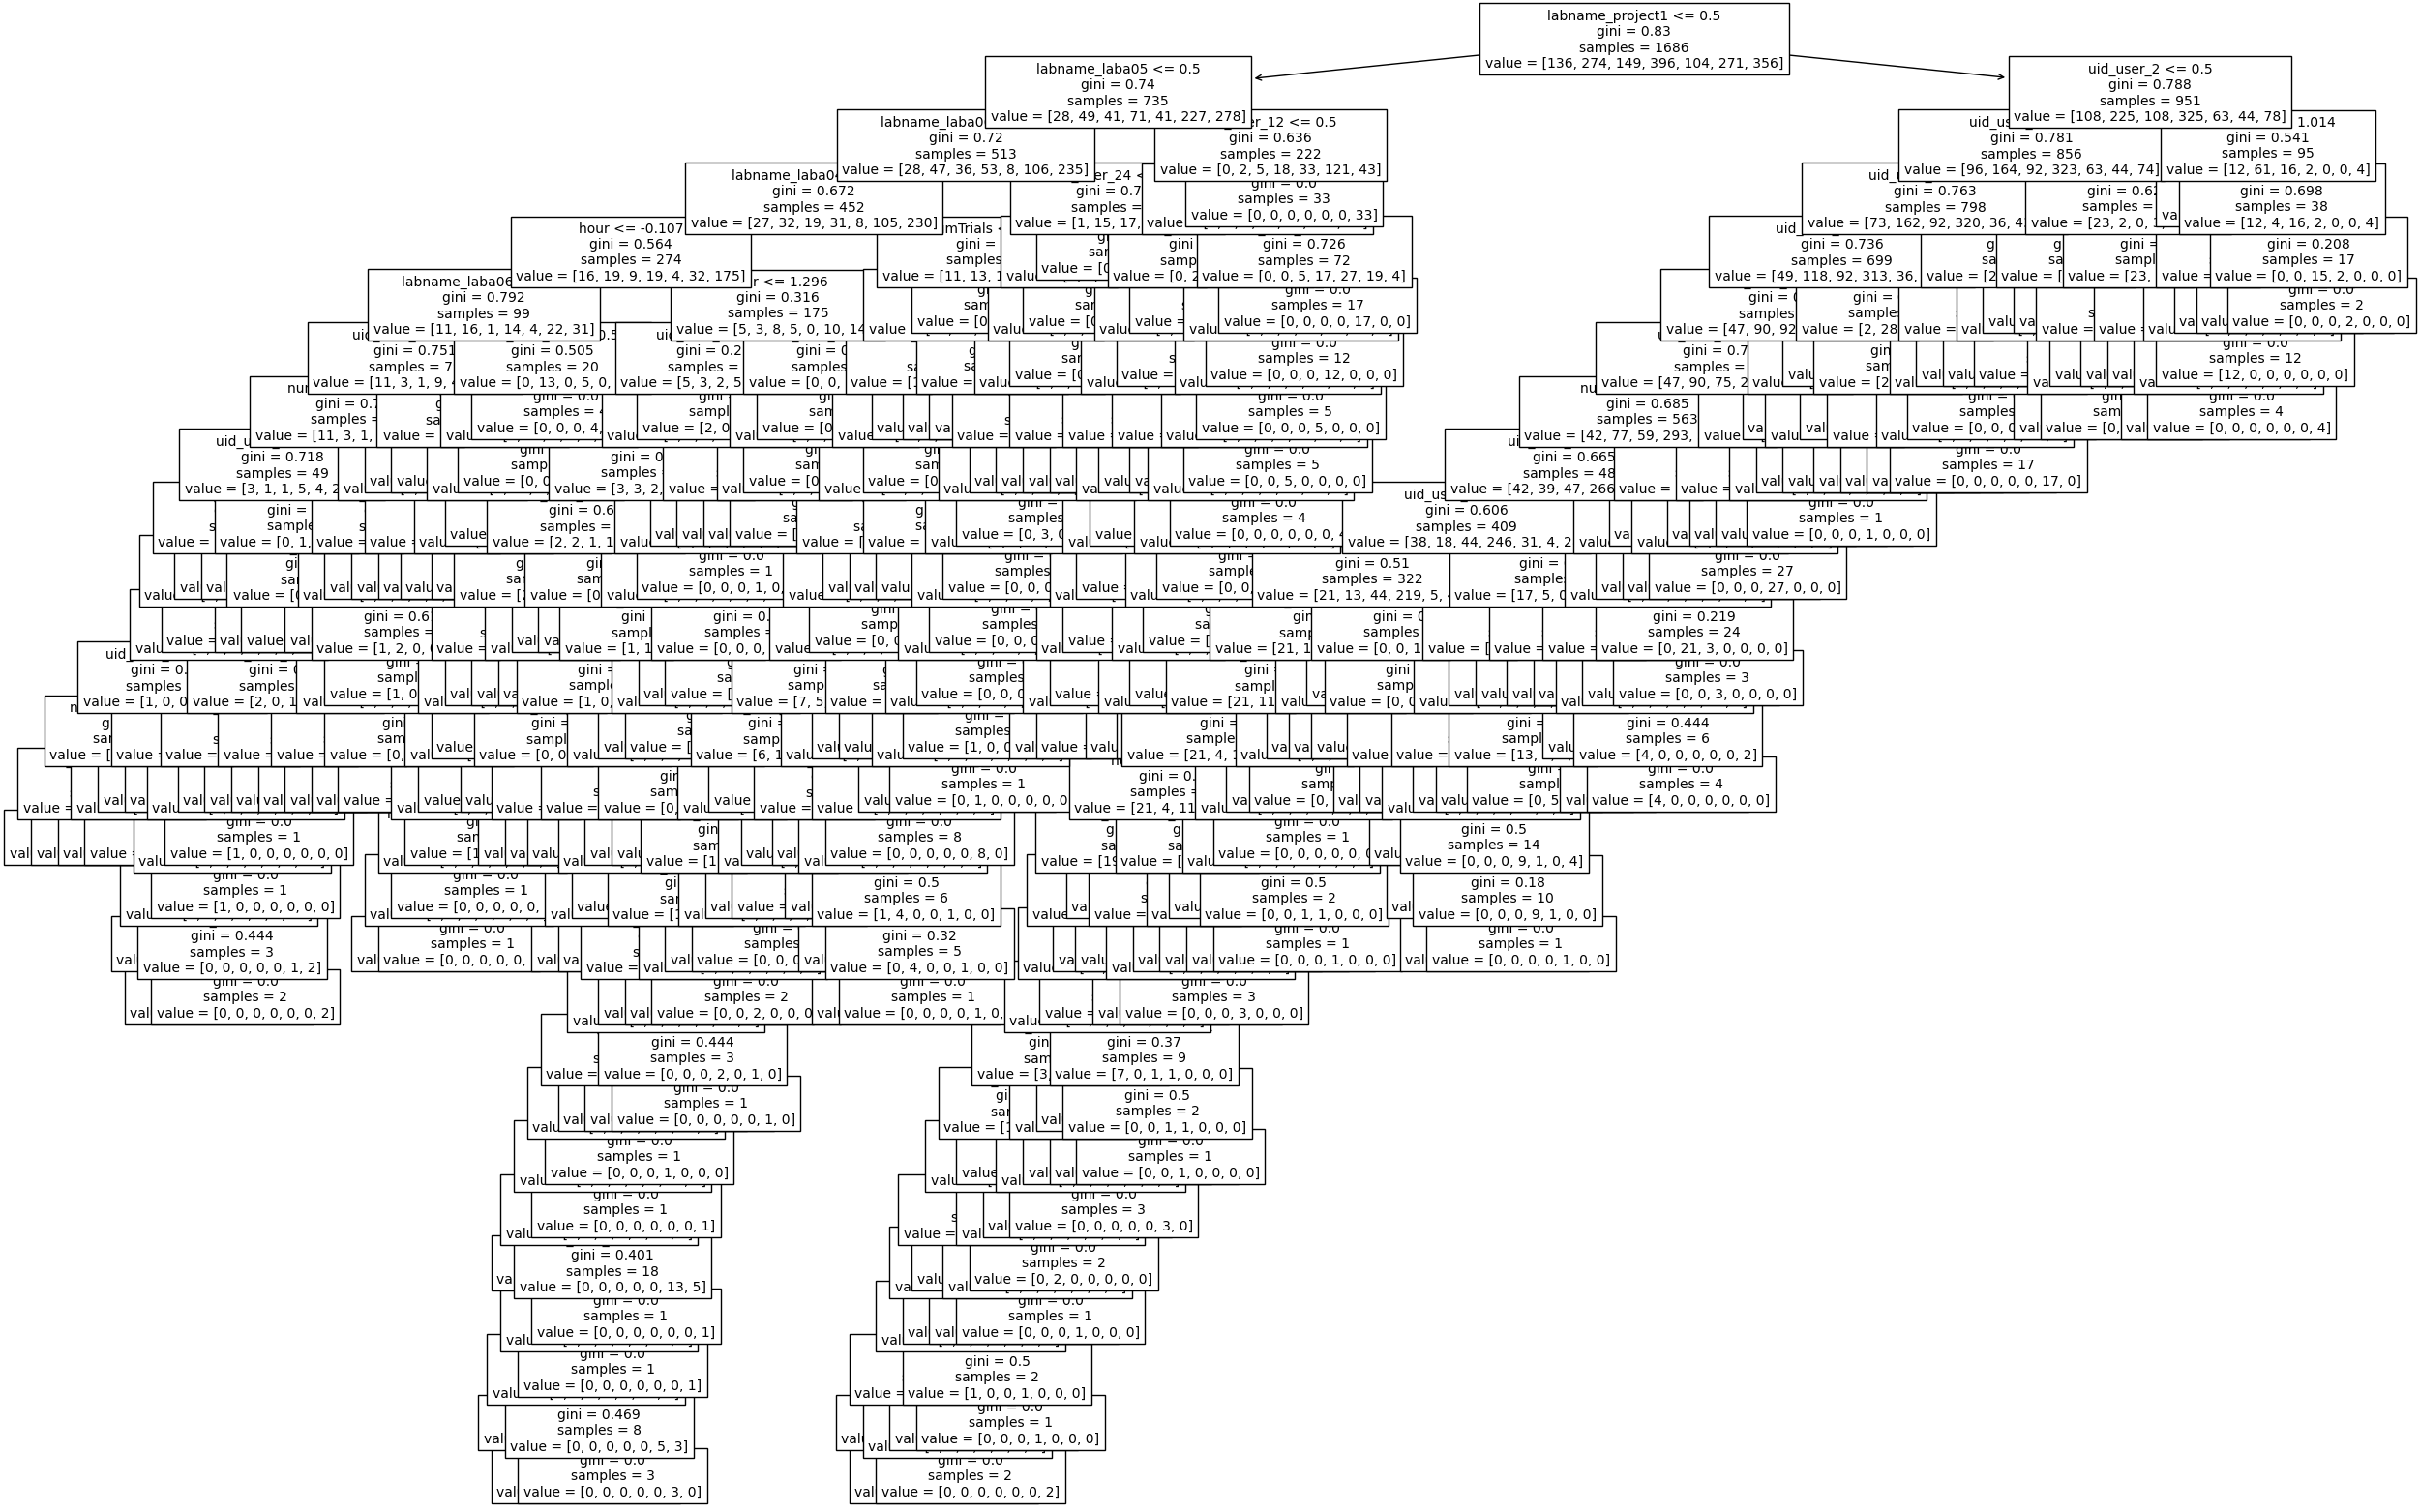

In [17]:
plt.figure(figsize=(30, 20))
plot_tree(model, feature_names=list(X.columns), fontsize=10)
plt.show()

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [18]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)

rfc = rfc.fit(X, y)

y_pred = rfc.predict(X)

accuracy = accuracy_score(y, y_pred)

accuracy

1.0

In [19]:
grid_space = {
    'max_depth': [5, 15, 20, 25],
    'n_estimators':[10, 100, 150, 300, 500]
}

model = RandomForestClassifier(random_state=21)

grid = GridSearchCV(
    model, 
    param_grid=grid_space, 
    cv=5, 
    scoring='accuracy'
    )

model_grid = grid.fit(X, y)

print('Лучшие гиперпараметры: ' +str(model_grid.best_params_))
model_grid.score(X, y)

Лучшие гиперпараметры: {'max_depth': 20, 'n_estimators': 150}


0.9976275207591934

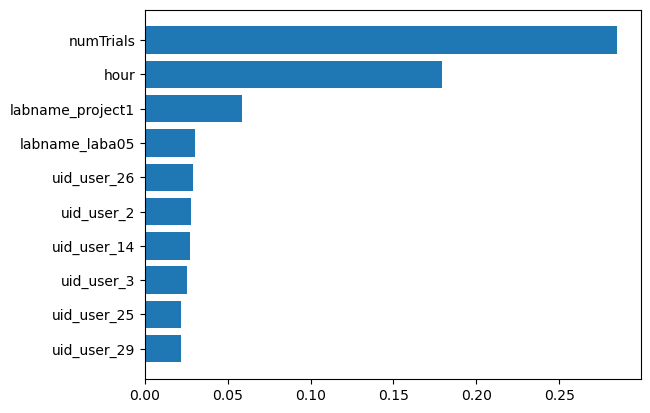

In [20]:
plot_barh(rfc.feature_importances_, X.columns)